In [28]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [29]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [30]:
X

array([[ 6.90901465, -6.90932138],
       [-8.3262084 , -1.76420187],
       [-0.29764364, -3.04882996],
       ...,
       [-9.86581365, -3.40890638],
       [ 9.02341511, -5.74309755],
       [ 8.80949166, -5.63589047]])

In [31]:
y

array([2, 0, 1, 1, 2, 2, 0, 2, 2, 0, 0, 2, 1, 1, 2, 2, 1, 1, 1, 0, 1, 2,
       1, 1, 0, 1, 2, 2, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 2, 1, 0, 2, 2, 2,
       2, 0, 2, 1, 1, 1, 0, 0, 1, 0, 0, 2, 1, 0, 2, 0, 1, 1, 2, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 2, 0, 1, 0, 2, 2, 1, 1, 0, 1, 0, 1, 1, 2,
       0, 1, 1, 2, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 2, 0,
       0, 1, 2, 2, 1, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 1, 0, 0, 1, 2,
       2, 2, 1, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 1, 2, 1, 0, 2, 0, 1, 2,
       2, 2, 0, 0, 0, 2, 0, 2, 2, 2, 0, 0, 1, 0, 2, 2, 0, 0, 0, 2, 2, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 2, 1, 1, 1, 0, 0, 1, 1, 2, 2, 1,
       0, 0, 2, 0, 1, 2, 1, 1, 2, 2, 0, 2, 2, 1, 2, 0, 2, 2, 2, 0, 1, 1,
       0, 2, 1, 0, 2, 0, 1, 1, 0, 2, 0, 2, 1, 1, 2, 1, 2, 1, 0, 2, 1, 2,
       1, 0, 1, 2, 2, 1, 0, 1, 0, 2, 1, 2, 2, 2, 0, 1, 0, 1, 0, 1, 0, 0,
       2, 2, 1, 0, 0, 2, 1, 0, 1, 2, 0, 2, 0, 0, 1, 1, 0, 0, 0, 2, 2, 0,
       0, 0, 2, 1, 1, 1, 1, 2, 0, 2, 1, 1, 2, 2, 0,

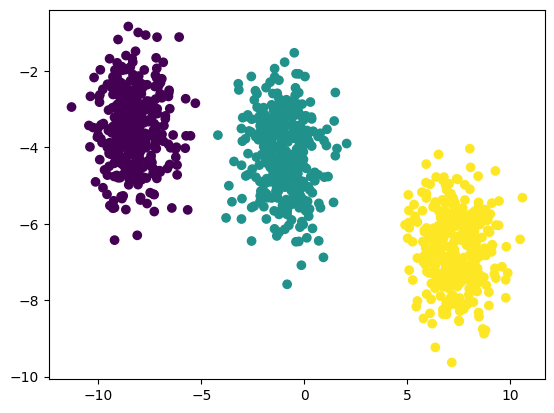

In [32]:
plt.scatter(X[:,0],X[:,1],c=y)

In [33]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [36]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [37]:
from sklearn.cluster import KMeans

In [38]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [39]:
wcss

[1340.0000000000002,
 386.18507756690485,
 245.87215724730902,
 192.3899036921655,
 148.16919676467455,
 130.5694161705909,
 86.50193098586948,
 71.51939482991139,
 59.3338195160123,
 53.40219506388674]

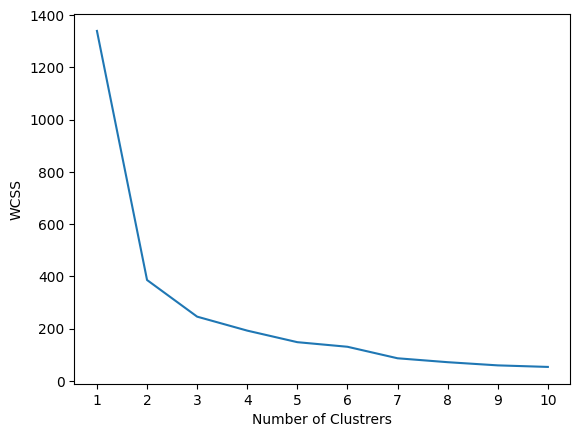

In [40]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [41]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [42]:
kmeans.fit_predict(X_train_scaled)

array([1, 1, 1, 1, 2, 2, 0, 1, 2, 2, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2,
       1, 1, 2, 1, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 2, 0, 2, 1, 0,
       2, 2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 2, 0, 2, 1, 2,
       0, 1, 0, 2, 0, 1, 2, 2, 0, 0, 2, 0, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1,
       1, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2, 1, 2, 1, 2, 0, 2, 0, 1, 2, 2,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 2, 0, 1, 0, 2, 1, 2, 1, 0, 1, 2, 1,
       1, 2, 2, 0, 1, 1, 2, 0, 0, 1, 1, 0, 2, 1, 0, 0, 2, 0, 1, 1, 0, 1,
       1, 1, 2, 0, 0, 2, 1, 2, 1, 1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 2, 2,
       1, 0, 2, 0, 1, 2, 2, 2, 2, 1, 0, 0, 0, 1, 2, 2, 0, 0, 2, 0, 1, 1,
       1, 2, 0, 1, 2, 0, 1, 1, 2, 1, 2, 2, 2, 1, 1, 2, 0, 1, 1, 1, 1, 0,
       2, 1, 2, 2, 2, 1, 1, 2, 0, 1, 1, 0, 1, 1, 2, 2, 2, 1, 2, 0, 1, 0,
       1, 2, 1, 1, 1, 0, 0, 0, 2, 2, 1, 0, 0, 1, 2, 2, 1, 1, 2, 1, 0, 0,
       2, 0, 1, 1, 0, 1, 2, 1, 0, 0, 0, 2, 2, 0, 1,

In [43]:
y_pred=kmeans.predict(X_test_scaled)

In [44]:
y_pred

array([2, 1, 2, 0, 1, 1, 1, 0, 1, 2, 1, 0, 1, 0, 0, 2, 1, 2, 2, 0, 0, 2,
       0, 1, 2, 0, 0, 0, 2, 0, 2, 1, 2, 0, 0, 1, 2, 2, 2, 1, 0, 0, 0, 2,
       2, 1, 2, 2, 0, 0, 1, 2, 0, 2, 0, 2, 0, 1, 2, 1, 0, 1, 0, 2, 1, 2,
       1, 0, 1, 1, 0, 2, 1, 2, 0, 0, 1, 0, 2, 1, 0, 1, 2, 0, 0, 2, 2, 0,
       2, 2, 1, 1, 1, 0, 2, 0, 0, 1, 0, 1, 2, 0, 2, 1, 2, 2, 0, 1, 2, 2,
       0, 0, 0, 0, 0, 2, 1, 2, 1, 1, 2, 1, 2, 1, 0, 1, 1, 2, 2, 0, 2, 0,
       2, 0, 0, 2, 0, 2, 0, 1, 2, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 1, 1, 1,
       2, 1, 2, 2, 0, 1, 0, 2, 0, 2, 1, 0, 2, 2, 0, 1, 2, 0, 1, 0, 1, 2,
       2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 1, 2, 1, 2, 0, 2, 2, 1, 1, 0, 1, 1,
       1, 2, 0, 2, 2, 0, 2, 0, 1, 0, 0, 0, 0, 1, 2, 2, 0, 1, 1, 2, 2, 2,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 2, 1, 2, 1, 2, 0, 1, 0, 0, 0,
       0, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 0, 0, 0,
       1, 0, 2, 0, 2, 0, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 1, 2, 2, 0, 0, 0,
       1, 1, 0, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 2, 1,

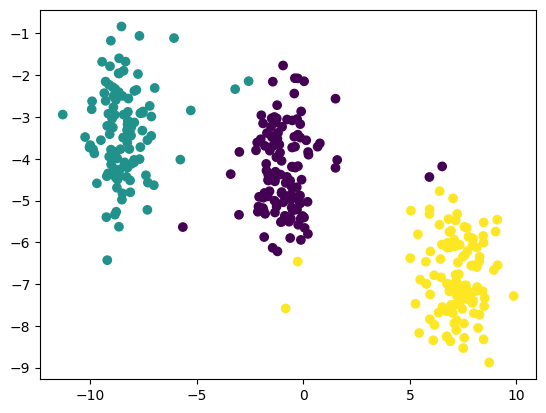

In [45]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [46]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [47]:
## kneelocator
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
from kneed import KneeLocator

In [49]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [50]:
kl.elbow

np.int64(2)

In [51]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [52]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [53]:
silhouette_coefficients

[np.float64(0.6085415396233516),
 np.float64(0.5238831805002218),
 np.float64(0.4624646690368938),
 np.float64(0.46696544634746867),
 np.float64(0.4788792327969674),
 np.float64(0.4750737591638321),
 np.float64(0.43964395472958734),
 np.float64(0.439405184680307),
 np.float64(0.4241122006494557)]

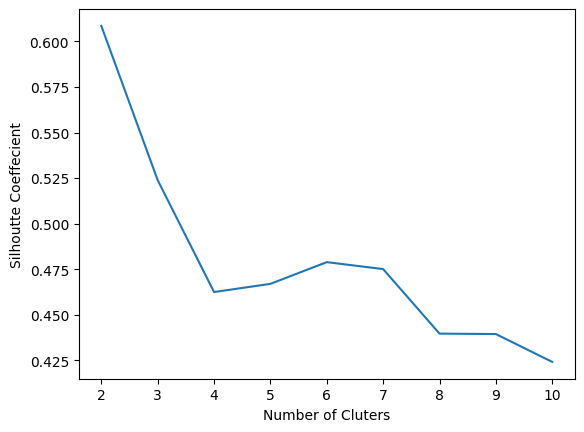

In [54]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()